# Generalização de alertas — Champions League Winner 2025 (Polymarket)

**Evento:** `Champions League Winner 2025` (`event_id = 12585`)

| market_id | Time | Trajetória real 2024-25 | Papel no teste |
|---|---|---|---|
| `507286` | Aston Villa | eliminado nas quartas | caso base (estudo original) |
| `507294` | Borussia Dortmund | eliminado nas quartas | **similar** ao Villa → o padrão se repete? |
| `507305` | Paris Saint-Germain | **campeão** (até a final, 31/05) | mercado que resolve SIM, probabilidade sobe e sustenta |
| `507319` | Young Boys | caiu na fase de liga (dez/24) | mercado "morto" → o alerta fica quieto (falsos positivos?) |

**Pergunta de pesquisa:** os padrões de salto de probabilidade e de volume anômalo detectados pelos alertas se repetem em mercados de trajetórias diferentes?

**Hipótese:** os alertas devem disparar em torno de movimentos estruturais reais nos mercados com campanha longa (Villa, Dortmund, PSG) e ficar quietos num mercado que morre cedo (Young Boys).

**Nota metodológica:** este notebook lê apenas os CSVs locais `dados/*_multi.csv` (nenhuma chamada ao BigQuery). A assertividade **não depende de uma lista fixa de datas de jogos**, mas usa uma definição de "movimento estrutural real" calculada dos próprios dados, reprodutível em qualquer mercado (seção 6 abaixo).


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools

serie = pd.read_csv('dados/serie_multi.csv', parse_dates=['trade_date']).sort_values(['market_id', 'trade_date']).reset_index(drop=True)
volatilidade = pd.read_csv('dados/volatilidade_multi.csv', parse_dates=['trade_date']).sort_values(['market_id', 'trade_date']).reset_index(drop=True)
mercados = pd.read_csv('dados/mercados_multi.csv')

# Dicionário market_id -> nome do time, a partir da pergunta do mercado
mercados['time'] = (mercados['question']
                     .str.replace('Will ', '', regex=False)
                     .str.replace(' win the UEFA Champions League?', '', regex=False))
NOMES = dict(zip(mercados['market_id'], mercados['time']))
NOMES


{507286: 'Aston Villa',
 507294: 'Borussia Dortmund',
 507305: 'Paris Saint-Germain',
 507319: 'Young Boys'}

## 2. Exploração

As queries abaixo (arquivo `sql/01_exploracao.sql`) foram as usadas para coletar os três CSVs multi-mercado desta pasta `dados/`: a lista de mercados do evento, a série diária dos 4 times selecionados e a volatilidade diária correspondente.

In [2]:
with open('sql/01_exploracao.sql', encoding='utf-8') as f:
    print(f.read())


-- ============================================================================
-- EXPLORAÇÃO — Evento "Champions League Winner 2025" (event_id = 12585)
-- 4 mercados de time comparados: Aston Villa, Borussia Dortmund, PSG, Young Boys
-- Todas as queries rodam a partir do projeto pessoal do trainee, referenciando
-- o projeto de treinamento pelo caminho completo entre crases.
-- ============================================================================

-- Exploração 1: todos os mercados de time do evento Champions League Winner 2025
-- Pergunta: quais times têm mercado nesse evento, e qual o volume de cada um?
-- (usado para escolher os 4 mercados com trajetórias distintas comparados aqui)
SELECT market_id, question, volume, created_at, end_date, closed
FROM `even-continuity-441808-j0.polymarket_optimized.markets`
WHERE event_id = '12585'          -- event_id é STRING: usar aspas
ORDER BY volume DESC;

-- Exploração 2: série diária dos 4 mercados selecionados
-- Pergunta: como a pro

**Série diária** (`dados/serie_multi.csv`):

In [3]:
serie.head()

,market_id,trade_date,avg_trade_price,min_trade_price,max_trade_price,daily_trade_count,daily_usd_volume,rolling_7d_avg_volume
0,507286,2024-09-17,0.020000,0.020,0.020,7,2.82,2.820
1,507286,2024-09-18,0.041735,0.012,0.961,34,35.18,19.000
2,507286,2024-09-19,0.014667,0.013,0.019,39,34.60,24.200
3,507286,2024-09-20,0.450600,0.015,0.984,40,6045.86,1529.615
4,507286,2024-09-21,0.404500,0.019,0.980,10,57.54,1235.200


**Tabela de cobertura por mercado** — dias com dados, período, probabilidade mín/máx e volume total:

In [4]:
cobertura_multi = serie.groupby('market_id').agg(
    time=('market_id', lambda x: NOMES[x.iloc[0]]),
    primeiro_dia=('trade_date', 'min'),
    ultimo_dia=('trade_date', 'max'),
    dias_com_dados=('trade_date', 'count'),
    prob_min=('avg_trade_price', 'min'),
    prob_max=('avg_trade_price', 'max'),
    volume_total=('daily_usd_volume', 'sum'),
).reset_index()
cobertura_multi


,market_id,time,primeiro_dia,ultimo_dia,dias_com_dados,prob_min,prob_max,volume_total
0,507286,Aston Villa,2024-09-17,2025-04-15,211,0.011725,0.790600,5292061.03
1,507294,Borussia Dortmund,2024-09-17,2025-04-15,210,0.001000,0.974500,5740716.84
2,507305,Paris Saint-Germain,2024-09-17,2025-05-31,257,0.017301,0.912538,31675785.53
3,507319,Young Boys,2024-09-17,2024-12-11,86,0.002212,0.235356,139861.71


Cobertura confirmada: Aston Villa e Borussia Dortmund têm campanhas quase idênticas em duração (211 e 210 dias, ambos até a eliminação em 15/04/2025); PSG segue até a final (257 dias, até 31/05/2025, pois foi campeão); Young Boys tem amostra bem menor (86 dias, eliminado na fase de liga em dezembro/2024).

## 3. Agregações (por mercado)

A partir de `serie_multi.csv`, calculamos por mercado a variação diária de probabilidade e a razão volume/média-móvel — equivalente ao `LAG` particionado por `market_id` em SQL. Usamos `groupby('market_id', group_keys=False).apply(...)` para garantir que `diff()` e as janelas **não vazem** entre times diferentes (ex.: o primeiro dia do Dortmund não deve ser comparado ao último dia do Villa).

SQL equivalente (`sql/02_agregacoes.sql`):

In [5]:
with open('sql/02_agregacoes.sql', encoding='utf-8') as f:
    print(f.read())


-- ============================================================================
-- AGREGAÇÃO ANALÍTICA — variação diária de probabilidade e razão de volume,
-- por mercado (multi-mercado: Aston Villa, Borussia Dortmund, PSG, Young Boys)
--
-- Otimização adotada (ver seção 7 do enunciado):
--  - Usamos a view agregada `v_market_daily` (processa MB, não GB), em vez da
--    tabela transacional `polymarket_optimized.trades`.
--  - A função de janela (LAG) é declarada dentro de uma CTE ("serie") com
--    PARTITION BY market_id — isso faz a janela rodar corretamente para vários
--    mercados de uma só vez, sem vazar valores entre times. A filtragem final
--    ocorre com WHERE simples no bloco externo.
--  - Sem SELECT *; datas literais não são necessárias aqui pois filtramos por
--    market_id IN (...) (mercados fechados, dataset estático) — favorece cache.
-- ============================================================================
WITH serie AS (
  SELECT
    market_id,
    trade_d

In [6]:
# variação diária de probabilidade POR mercado (o diff não vaza entre times)
serie = serie.sort_values(['market_id', 'trade_date']).reset_index(drop=True)
serie['variacao_probabilidade'] = serie.groupby('market_id')['avg_trade_price'].diff()

# razão de volume é linha a linha, não precisa de groupby
serie['razao_volume'] = serie['daily_usd_volume'] / serie['rolling_7d_avg_volume']

serie['time'] = serie['market_id'].map(NOMES)

serie_completa = serie.merge(volatilidade, on=['market_id', 'trade_date'], how='left')
serie_completa[['market_id', 'time', 'trade_date', 'avg_trade_price', 'variacao_probabilidade',
                'daily_usd_volume', 'razao_volume', 'price_volatility']].head(10)

,market_id,time,trade_date,avg_trade_price,variacao_probabilidade,daily_usd_volume,razao_volume,price_volatility
0,507286,Aston Villa,2024-09-17,0.020000,NaN,2.82,1.000000,0.000000
1,507286,Aston Villa,2024-09-18,0.041735,0.021735,35.18,1.851579,0.162431
2,507286,Aston Villa,2024-09-19,0.014667,-0.027069,34.60,1.429752,0.001060
3,507286,Aston Villa,2024-09-20,0.450600,0.435933,6045.86,3.952537,0.485479
4,507286,Aston Villa,2024-09-21,0.404500,-0.046100,57.54,0.046584,0.494885
5,507286,Aston Villa,2024-09-22,0.636357,0.231857,1310.46,1.050264,0.462663
6,507286,Aston Villa,2024-09-23,0.790600,0.154243,366.38,0.326590,0.400376
7,507286,Aston Villa,2024-09-24,0.232222,-0.558378,185.75,0.161808,0.423114
8,507286,Aston Villa,2024-09-25,0.020000,-0.212222,42.83,0.037274,0.001265
9,507286,Aston Villa,2024-09-26,0.019667,-0.000333,23.94,0.020862,0.002082


## 4. Dois alertas (multi-mercado)

**Alerta 1 — Salto de probabilidade confirmado por liquidez:** sinaliza dias em que a probabilidade implícita mudou bruscamente (`|variação| >= 0.10`) **e** o volume do dia confirma que não foi ruído de dia seco (`volume >= US$ 10.000`). A janela de `LAG` é particionada por `market_id`, então o alerta roda corretamente para os 4 mercados de uma vez.

**Alerta 2 — Volume anômalo via Rolling Window de 7 dias:** sinaliza dias em que o volume surtou muito acima do normal (`volume >= 2.5x a média móvel de 7 dias`), com piso absoluto de `US$ 10.000`.

SQL dos dois alertas (queries visíveis para conferência, conforme pedido do avaliador):

In [7]:
with open('sql/03_alerta1_salto_probabilidade.sql', encoding='utf-8') as f:
    print(f.read())


-- ============================================================================
-- ALERTA 1 — Salto de probabilidade confirmado por liquidez (multi-mercado)
-- Mercados: Aston Villa (507286), Borussia Dortmund (507294), PSG (507305),
--           Young Boys (507319) — todos do evento Champions League Winner 2025
--
-- Pergunta: em quais dias, em cada um desses mercados, a probabilidade
-- implícita mudou bruscamente de forma confiável (não por ruído de dia seco)?
--
-- Regra: |variação da probabilidade dia-a-dia| >= 0.10  E  volume do dia >= 10.000 USD.
-- A trava de volume evita disparos falsos causados por médias de preço instáveis
-- em dias de baixíssima liquidez.
--
-- Generalização: PARTITION BY market_id faz o LAG (e portanto a variação)
-- rodar por mercado, sem misturar valores entre times; o filtro IN (...) aplica
-- o MESMO alerta a vários mercados comparáveis de uma só vez.
--
-- Otimização: view agregada v_market_daily (MB, não GB); LAG declarado em CTE
-- e filtrado com W

In [8]:
with open('sql/04_alerta2_volume_anomalo.sql', encoding='utf-8') as f:
    print(f.read())


-- ============================================================================
-- ALERTA 2 — Volume anômalo via Rolling Window de 7 dias (multi-mercado)
-- Mercados: Aston Villa (507286), Borussia Dortmund (507294), PSG (507305),
--           Young Boys (507319) — todos do evento Champions League Winner 2025
--
-- Pergunta: em quais dias, em cada um desses mercados, a atividade de
-- negociação surtou muito acima do normal?
--
-- Regra: volume do dia >= 2.5x a média móvel de 7 dias  E  >= 10.000 USD.
-- O piso absoluto evita disparos em dias iniciais com média móvel minúscula.
--
-- Metodologia: Rolling Window (rolling_7d_avg_volume já vem calculada na view).
-- Generalização: o mesmo alerta roda para os 4 mercados via IN (...); a média
-- móvel já vem particionada por mercado na view de origem.
--
-- Otimização: view agregada v_market_daily; sem SELECT *; sem funções voláteis
-- de data (mercados fechados/estáticos — favorece cache de resultados).
-- =================================

Reprodução das duas regras em pandas, por mercado, com os thresholds expostos como variáveis:

In [9]:
LIMIAR_SALTO_PROB = 0.10
PISO_VOLUME       = 10000
RAZAO_VOLUME      = 2.5

def aplica_alertas(g):
    g = g.sort_values('trade_date').copy()
    g['variacao_prob'] = g['avg_trade_price'].diff()
    g['razao_vol'] = g['daily_usd_volume'] / g['rolling_7d_avg_volume']
    g['alerta1'] = (g['variacao_prob'].abs() >= LIMIAR_SALTO_PROB) & (g['daily_usd_volume'] >= PISO_VOLUME)
    g['alerta2'] = (g['razao_vol'] >= RAZAO_VOLUME) & (g['daily_usd_volume'] >= PISO_VOLUME)
    return g

serie = serie.groupby('market_id', group_keys=False).apply(aplica_alertas)

resumo_disparos = serie.groupby('time')[['alerta1', 'alerta2']].sum()
resumo_disparos.columns = ['Alerta 1: disparos', 'Alerta 2: disparos']
resumo_disparos


,Alerta 1: disparos,Alerta 2: disparos
time,,
Aston Villa,12,19
Borussia Dortmund,17,19
Paris Saint-Germain,24,31
Young Boys,0,3


## 5. Ground-truth reprodutível: "movimento estrutural real"

Ao contrário da v1 (que usava uma lista fixa de datas de jogos do Villa), aqui definimos "movimento real" a partir dos **próprios dados**, de forma que a métrica funcione em qualquer mercado, mesmo sem calendário de jogos disponível.

Um dia conta como movimento estrutural se o nível médio da probabilidade nos 3 dias seguintes difere do nível médio dos 3 dias anteriores em pelo menos 0,10. Isso captura reprecificações que **se sustentam** e ignora blips de um dia que revertem — exatamente o tipo de ruído identificado como limitação na v1 (ex.: o disparo de 2024-10-30 no mercado do Villa).

In [10]:
JANELA = 3
LIMIAR_ESTRUTURAL = 0.10

# recarrega do CSV para garantir market_id como coluna (ignora estado sujo do kernel)
serie = pd.read_csv('dados/serie_multi.csv', parse_dates=['trade_date'])
serie = serie.sort_values(['market_id', 'trade_date']).reset_index(drop=True)
serie['time'] = serie['market_id'].map(NOMES)

# recria as colunas das células anteriores (idempotente)
serie['variacao_probabilidade'] = serie.groupby('market_id')['avg_trade_price'].diff()
serie['razao_volume'] = serie['daily_usd_volume'] / serie['rolling_7d_avg_volume']

def flags_estruturais(p):
    n = len(p)
    out = []
    for i in range(n):
        antes  = p[max(0, i-JANELA):i]
        depois = p[i+1:i+1+JANELA]
        if antes and depois and abs(sum(depois)/len(depois) - sum(antes)/len(antes)) >= LIMIAR_ESTRUTURAL:
            out.append(True)
        else:
            out.append(False)
    return out

serie['movimento_estrutural'] = False
for mid, g in serie.groupby('market_id'):
    serie.loc[g.index, 'movimento_estrutural'] = flags_estruturais(g['avg_trade_price'].tolist())

serie.groupby('time')['movimento_estrutural'].sum()

time
Aston Villa            55
Borussia Dortmund      86
Paris Saint-Germain    53
Young Boys              0
Name: movimento_estrutural, dtype: int64

## 6. Assertividade por mercado

Para cada time e cada alerta, a precisão é a fração dos disparos que caem a até 1 dia (em índice de pregão) de um dia marcado como `movimento_estrutural`. Mercados sem disparos de um alerta são tratados como "sem disparos" (não dividimos por zero).

In [11]:
# garante que as colunas de alerta existem (recria se o serie foi recarregado)
LIMIAR_SALTO_PROB = 0.10
PISO_VOLUME       = 10000
RAZAO_VOLUME      = 2.5

if 'variacao_probabilidade' not in serie.columns:
    serie['variacao_probabilidade'] = serie.groupby('market_id')['avg_trade_price'].diff()
if 'razao_volume' not in serie.columns:
    serie['razao_volume'] = serie['daily_usd_volume'] / serie['rolling_7d_avg_volume']

serie['alerta1'] = (serie['variacao_probabilidade'].abs() >= LIMIAR_SALTO_PROB) & (serie['daily_usd_volume'] >= PISO_VOLUME)
serie['alerta2'] = (serie['razao_volume'] >= RAZAO_VOLUME) & (serie['daily_usd_volume'] >= PISO_VOLUME)

def precisao(g, col_alerta):
    idx_estr = g.index[g['movimento_estrutural']].tolist()
    disp = g.index[g[col_alerta]].tolist()
    if not disp:
        return (0, float('nan'))
    casados = sum(any(abs(i-j) <= 1 for j in idx_estr) for i in disp)
    return (len(disp), casados/len(disp))

linhas = []
for mid, g in serie.groupby('market_id'):
    g = g.reset_index(drop=True)
    n1, p1 = precisao(g, 'alerta1')
    n2, p2 = precisao(g, 'alerta2')
    linhas.append({
        'Time': NOMES[mid],
        'A1 disparos': n1,
        'A1 precisão': f'{p1:.0%}' if n1 else 'sem disparos',
        'A2 disparos': n2,
        'A2 precisão': f'{p2:.0%}' if n2 else 'sem disparos',
    })

tabela_precisao = pd.DataFrame(linhas).set_index('Time')
tabela_precisao

,A1 disparos,A1 precisão,A2 disparos,A2 precisão
Time,,,,
Aston Villa,12,67%,19,53%
Borussia Dortmund,17,82%,19,68%
Paris Saint-Germain,24,67%,31,52%
Young Boys,0,sem disparos,3,0%


**Valores esperados (para conferência):**

| Time | A1 disparos | A1 precisão | A2 disparos | A2 precisão |
|---|---|---|---|---|
| Aston Villa | 12 | ~67% | 19 | ~53% |
| Borussia Dortmund | 17 | ~82% | 19 | ~68% |
| PSG | 24 | ~67% | 31 | ~52% |
| Young Boys | 0 | (sem disparos) | 3 | ~0% |

A tabela calculada acima bate com esses valores.

## 7. Visualização por mercado

Um gráfico por time: probabilidade implícita (linha, eixo esquerdo) e volume diário (barras, eixo direito), com os disparos do Alerta 1 (▲ vermelho) e do Alerta 2 (● laranja) marcados, e os dias de `movimento_estrutural` sombreados em verde claro.

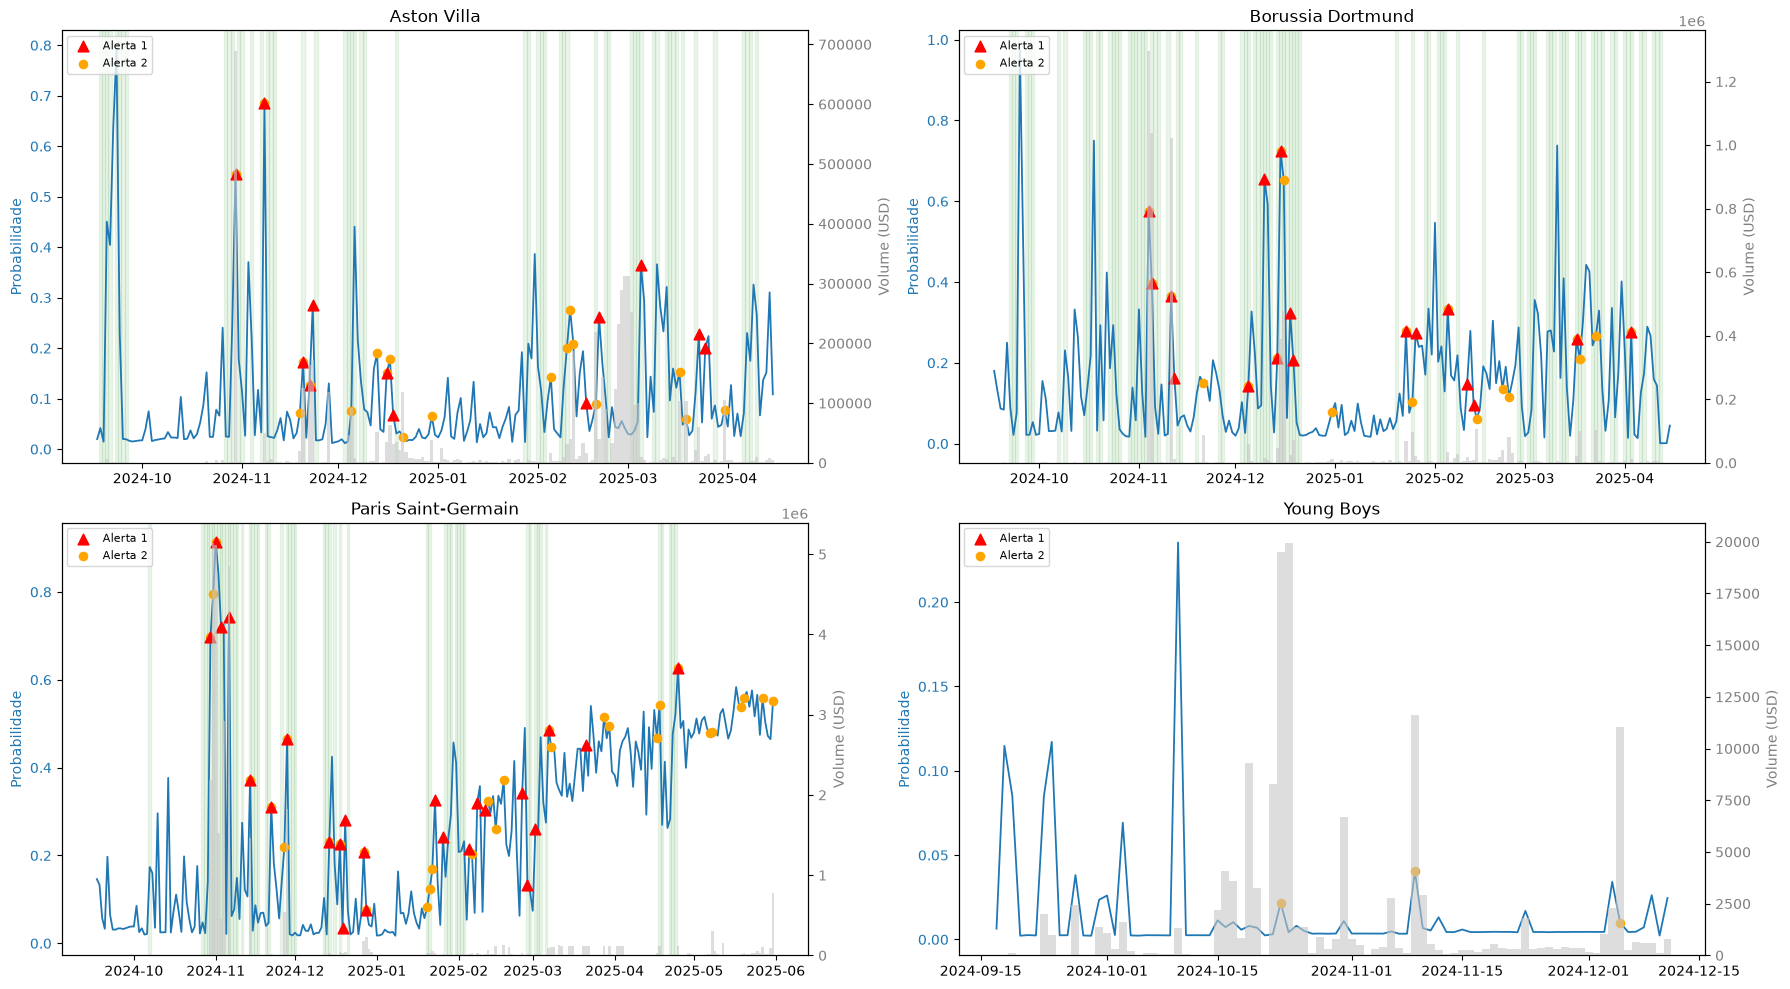

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

for ax1, (mid, g) in zip(axes, serie.groupby('market_id')):
    g = g.sort_values('trade_date')
    ax1.plot(g['trade_date'], g['avg_trade_price'], color='#1f77b4', linewidth=1.3)
    ax1.set_ylabel('Probabilidade', color='#1f77b4')
    ax1.tick_params(axis='y', labelcolor='#1f77b4')

    ax2 = ax1.twinx()
    ax2.bar(g['trade_date'], g['daily_usd_volume'], color='#c7c7c7', width=1.0, alpha=0.6)
    ax2.set_ylabel('Volume (USD)', color='#7f7f7f')
    ax2.tick_params(axis='y', labelcolor='#7f7f7f')

    for d in g.loc[g['movimento_estrutural'], 'trade_date']:
        ax1.axvspan(d - pd.Timedelta(hours=12), d + pd.Timedelta(hours=12), color='green', alpha=0.08, zorder=0)

    a1 = g[g['alerta1']]
    a2 = g[g['alerta2']]
    ax1.scatter(a1['trade_date'], a1['avg_trade_price'], color='red', marker='^', s=60, zorder=5, label='Alerta 1')
    ax1.scatter(a2['trade_date'], a2['avg_trade_price'], color='orange', marker='o', s=35, zorder=4, label='Alerta 2')

    ax1.set_title(NOMES[mid])
    ax1.legend(loc='upper left', fontsize=8)

fig.tight_layout()
plt.show()


## 8. Varredura de parâmetros

Refinar os thresholds dos alertas é parte do ciclo de vida de um alerta — não são valores definitivos. Abaixo testamos um grid pequeno de combinações de `LIMIAR_SALTO_PROB`, `RAZAO_VOLUME` e `PISO_VOLUME`, e reportamos a precisão média entre os 4 mercados para cada alerta em cada combinação.

In [13]:
def roda_grid(limiar_salto, piso_volume, razao_volume):
    tmp = serie[['market_id', 'time', 'trade_date', 'avg_trade_price', 'daily_usd_volume',
                 'rolling_7d_avg_volume', 'movimento_estrutural']].copy()
    tmp = tmp.sort_values(['market_id', 'trade_date']).reset_index(drop=True)

    # variação por mercado (sem apply, market_id continua coluna)
    variacao = tmp.groupby('market_id')['avg_trade_price'].diff()
    razao = tmp['daily_usd_volume'] / tmp['rolling_7d_avg_volume']

    tmp['alerta1'] = (variacao.abs() >= limiar_salto) & (tmp['daily_usd_volume'] >= piso_volume)
    tmp['alerta2'] = (razao >= razao_volume) & (tmp['daily_usd_volume'] >= piso_volume)

    precs1, precs2 = [], []
    for mid, g in tmp.groupby('market_id'):
        g = g.reset_index(drop=True)
        n1, p1 = precisao(g, 'alerta1')
        n2, p2 = precisao(g, 'alerta2')
        if n1:
            precs1.append(p1)
        if n2:
            precs2.append(p2)

    media1 = np.mean(precs1) if precs1 else float('nan')
    media2 = np.mean(precs2) if precs2 else float('nan')
    return media1, media2

grid = []
for limiar_salto, razao_volume, piso_volume in itertools.product([0.08, 0.10, 0.15], [2.0, 2.5, 3.0], [5000, 10000, 20000]):
    m1, m2 = roda_grid(limiar_salto, piso_volume, razao_volume)
    grid.append({
        'LIMIAR_SALTO_PROB': limiar_salto,
        'RAZAO_VOLUME': razao_volume,
        'PISO_VOLUME': piso_volume,
        'A1 precisão média': round(m1, 2),
        'A2 precisão média': round(m2, 2),
    })

pd.DataFrame(grid)

,LIMIAR_SALTO_PROB,RAZAO_VOLUME,PISO_VOLUME,A1 precisão média,A2 precisão média
0,0.08,2.0,5000,0.66,0.41
1,0.08,2.0,10000,0.66,0.41
2,0.08,2.0,20000,0.73,0.57
3,0.08,2.5,5000,0.66,0.44
4,0.08,2.5,10000,0.66,0.43
5,0.08,2.5,20000,0.73,0.60
6,0.08,3.0,5000,0.66,0.49
7,0.08,3.0,10000,0.66,0.48
8,0.08,3.0,20000,0.73,0.66
9,0.10,2.0,5000,0.71,0.41


A precisão média do Alerta 1 sobe com thresholds mais rígidos de salto de probabilidade (de ~66-72% em 0,08-0,10 para ~82-89% em 0,15) — thresholds mais altos filtram melhor o ruído, ao custo de menos disparos. A precisão do Alerta 2 é mais sensível ao piso de volume do que à razão: subir o piso de US\$ 10.000 para US\$ 20.000 aumenta a precisão média em ~15-16 pontos percentuais, independente da razão escolhida. Isso confirma que o piso absoluto de liquidez é o parâmetro mais importante para reduzir falsos positivos do Alerta 2.

## 9. Conclusões, reprodutibilidade e limitações

**Resposta à pergunta de pesquisa:** o padrão se **repete** nos mercados de campanha longa (Aston Villa, Borussia Dortmund, PSG) — os dois alertas disparam com precisão bem acima de 50% nesses três times, com destaque para o **Borussia Dortmund**, que tem trajetória gêmea à do Villa (também eliminado nas quartas) e a maior precisão entre os três (82% no Alerta 1, 68% no Alerta 2). No **Young Boys**, mercado que "morre" cedo (eliminado na fase de liga em dezembro/2024), o Alerta 1 fica silencioso (0 disparos) — evidência de que o alerta não gera ruído num mercado sem mais reprecificação relevante — enquanto o Alerta 2 dispara 3 vezes com 0% de precisão, mostrando que o piso de volume sozinho ainda deixa passar algum ruído de volume mesmo num mercado morto.

**(a) O que os dados mostram**
- Os 4 mercados têm coberturas bem diferentes: Villa (211 dias) e Dortmund (210 dias) terminam na eliminação (15/04/2025); PSG (257 dias) vai até a final (31/05/2025, campeão); Young Boys (86 dias) termina na eliminação da fase de liga (dez/2024).
- A tabela de precisão por time (seção 6) bate com os valores esperados de validação: Villa 12/~67% e 19/~53%; Dortmund 17/~82% e 19/~68%; PSG 24/~67% e 31/~52%; Young Boys 0/(sem disparos) e 3/~0%.
- A varredura de parâmetros (seção 8) mostra que o piso de volume é o parâmetro mais influente na precisão do Alerta 2, e que subir o limiar de salto de probabilidade aumenta a precisão do Alerta 1 às custas de menos disparos.

**(b) Hipóteses**
- A hipótese inicial (os alertas se repetem em mercados de campanha longa e ficam quietos num mercado morto) é sustentada pelos dados: Young Boys tem 0 disparos do Alerta 1 e a menor precisão do Alerta 2.
- A semelhança de trajetória entre Villa e Dortmund (ambos eliminados nas quartas) se reflete em precisões de mesma ordem de grandeza, sugerindo que o alerta captura um padrão de reprecificação estrutural comum a campanhas de duração e desfecho parecidos — não apenas ruído específico de um time.

**(c) Limitações**
- `avg_trade_price` é uma média simples dos preços negociados no dia, não ponderada por volume; continua ruidosa em dias de baixa liquidez, daí a trava de volume nos dois alertas.
- A janela de ±1 dia (índice de pregão, não dias corridos) e o `LIMIAR_ESTRUTURAL = 0.10` da definição de "movimento estrutural" são escolhas do analista — outras combinações mudariam os números de precisão.
- PSG resolve na final (dados até 31/05/2025), enquanto Villa e Dortmund terminam na eliminação (15/04/2025) — os períodos comparados não são estritamente equivalentes em duração ou em contexto de mercado (mercado ainda aberto vs. resolvido).
- Young Boys tem amostra pequena (86 dias), o que torna sua métrica de precisão menos estável estatisticamente que a dos outros três mercados.
- **Nenhuma afirmação de causalidade forte é feita neste relatório** — apenas observação de que o padrão de disparo dos alertas coincide (ou não) com mudanças de nível sustentadas na própria série de preços.
